In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from matplotlib.patches import Ellipse
from skimage.measure import EllipseModel

import sympy as sm
import sympy.physics.mechanics as me
from matplotlib import collections as mc
import json

In [2]:
def readEllipse(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    ellipses = []

    for line in lines:
        parts = list(map(float, line.strip().split()))

        class_id = int(parts[0])
        points = np.array(parts[1:]).reshape(-1, 2)
        center = np.mean(points, axis=0)
        centered_points = points - center
        cov = np.cov(centered_points.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        major_axis = 2 * math.sqrt(max(eigenvalues))
        minor_axis = 2 * math.sqrt(min(eigenvalues))
        angle = math.degrees(math.atan2(eigenvectors[1, 0], eigenvectors[0, 0]))

        ellipses.append({
            'class_id': class_id,
            'center': center,
            'major_axis': major_axis,
            'minor_axis': minor_axis,
            'angle': angle,
            'points': points
        })

    return ellipses

In [3]:
def yolo2scatter(list):
    x = []
    y = []

    for i in list:
        x.append(i[0])
        y.append(i[1])

    return np.array(x), np.array(y)

In [4]:
def params2ellipse(center, major_axis, minor_axis, angle):
    
    # Ellipse parameters
    # x0, y0 = center
    x0 = center[0]
    y0 = 1-center[1] # Invert y-axis for correct orientation
    theta = np.radians(angle)

    # Semi-major and semi-minor axes
    a = major_axis / 2
    b = minor_axis / 2

    # Parametric angle
    t = np.linspace(0, 2 * np.pi, 500)

    # Parametric equations for rotated ellipse
    x = x0 + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
    y = y0 + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)

    # Plotting
    # plt.figure(figsize=(6, 6))
    # plt.plot(x, y, label='Ellipse')
    # plt.scatter(x0, y0, color='red', label='Center')
    # plt.axis('equal')
    # plt.title('Ellipse Reconstruction')
    # plt.xlabel('X')
    # plt.ylabel('Y')
    # # plt.xlim(0, 1)
    # # plt.ylim(0, 1)
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return x, y, x0, y0

In [5]:
def findExtremes(points, screen_res):
    points = np.array(points)
    x_coords = points[:, 0] * screen_res[0]
    y_coords = (1-points[:, 1]) * screen_res[1]

    # The -1 in y_coords is due to the change of axis (y = 1 - y)

    min_x = np.min(x_coords); idx_min_x = np.argmin(x_coords)
    max_x = np.max(x_coords); idx_max_x = np.argmax(x_coords)
    min_y = np.min(y_coords); idx_min_y = np.argmin(y_coords)
    max_y = np.max(y_coords); idx_max_y = np.argmax(y_coords)

    bottom_coord = np.array([x_coords[idx_min_y], min_y])
    top_coord = np.array([x_coords[idx_max_y], max_y])
    left_coord = np.array([min_x, y_coords[idx_min_x]])
    right_coord = np.array([max_x, y_coords[idx_max_x]])
    
    vertical_dist = np.sqrt((top_coord[0]-bottom_coord[0])**2 + (top_coord[1]-bottom_coord[1])**2)
    horizontal_dist = np.sqrt((right_coord[0]-left_coord[0])**2 + (right_coord[1]-left_coord[1])**2)

    distances = np.array([vertical_dist, horizontal_dist])

    return bottom_coord, top_coord, left_coord, right_coord, distances

In [6]:
def calc_unit_vectors(ellipse_front, ellipse_rear):
    '''
    Calculate the unit vectors attached to the ellipses
    '''

    xf, yf = ellipse_front['center']
    xr, yr = ellipse_rear['center']

    a_f = ellipse_front['major_axis']
    b_f = ellipse_front['minor_axis']

    a_r = ellipse_rear['major_axis']
    b_r = ellipse_rear['minor_axis']

    theta_f = np.pi - ellipse_front['angle']
    theta_r = ellipse_rear['angle']

    if xf <= xr:
        x1f, y1f = [xf, xf + b_f*np.cos(theta_f)], [yf, yf + b_f*np.sin(theta_f)]
        x2f, y2f = [xf, xf - a_f*np.sin(theta_f)], [yf, yf + a_f*np.cos(theta_f)]

        x1r, y1r = [xr, xr + b_r*np.cos(theta_r)], [yr, yr + b_r*np.sin(theta_r)]
        x2r, y2r = [xr, xr - a_r*np.sin(theta_r)], [yr, yr + a_r*np.cos(theta_r)]
    else:
        x1f, y1f = [xf, xf + b_f*np.cos(np.pi - theta_f)], [yf, yf - b_f*np.sin(np.pi - theta_f)]
        x2f, y2f = [xf, xf + a_f*np.sin(np.pi - theta_f)], [yf, yf + a_f*np.cos(np.pi - theta_f)]

        x1r, y1r = [xr, xr + b_r*np.cos(np.pi - theta_r)], [yr, yr - b_r*np.sin(np.pi - theta_r)]
        x2r, y2r = [xr, xr + a_r*np.sin(np.pi - theta_r)], [yr, yr + a_r*np.cos(np.pi - theta_r)]

    horizontal_f = [x2f, y2f]
    vertical_f = [x1f, y1f]

    horizontal_r = [x2r, y2r]
    vertical_r = [x1r, y1r]

    vectors_f = [horizontal_f, vertical_f]
    vectors_r = [horizontal_r, vertical_r]

    return vectors_f, vectors_r

In [8]:
def print_ellipse(ellipse):

    a = ellipse['minor_axis']
    b = ellipse['major_axis']
    center = ellipse['center']
    angle_rotation = ellipse['angle']

    plt.figure(figsize=(6,6))
    plt.gca().set_aspect('equal')
    ellipse = Ellipse(center, width = 2*a, height = 2*b,
                      angle = angle_rotation, edgecolor='blue', facecolor='none')
    plt.gca().add_patch(ellipse)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.plot()

    return

In [9]:
def find_angle(ellipse, threshold, print_scores = False, increment = 1, print_increment = False):
    angle_y = 0
    match_score = 10
    k = 0.1 # weight for angle difference in match score
    iteration_counter = 0
    shrink = shrink = np.cos(np.radians(angle_y))

    optimal_ellipse = {'center': ellipse['center'],
                 'major_axis': ellipse['major_axis'],
                 'angle': ellipse['angle']}
    
    # angle_rotation_normal = ellipse['angle']/np.pi
    # Maybe the algorithm can be improved by reducing the increment when the
    # match score increases or goes to negative (not using np.abs, of course).

    while match_score > threshold:
        shrink = np.cos(np.radians(angle_y))
        optimal_ellipse = {'center': ellipse['center'],
                 'major_axis': ellipse['major_axis'],
                 'minor_axis': ellipse['major_axis']*shrink,
                 'angle': ellipse['angle']}
        
        match_score_euclidean = np.sqrt((ellipse['major_axis'] - optimal_ellipse['major_axis'])**2 + 
                                        (ellipse['minor_axis'] - optimal_ellipse['minor_axis'])**2 +
                                        k*(ellipse['angle'] - optimal_ellipse['angle'])**2)

        match_score_area = np.abs(np.pi*ellipse['major_axis']*ellipse['minor_axis'] - 
                                  np.pi*optimal_ellipse['major_axis']*optimal_ellipse['minor_axis'])

        match_score_ratio = np.abs(ellipse['major_axis']/ellipse['minor_axis'] -
                                   optimal_ellipse['major_axis']/(optimal_ellipse['minor_axis']))

        match_score = min([match_score_euclidean, match_score_area, match_score_ratio])

        if angle_y > 90:
            increment = increment/2
            angle_y = 0
            if print_increment:
                print('New increment: ', increment)

        angle_y += increment
        iteration_counter += 1
        

    if print_scores:
        print('euclidean_diff = ', match_score_euclidean)
        print('area_diff = ', match_score_area)
        print('ratio_diff = ', match_score_ratio)
        
    print('iterations = ', iteration_counter)
    return angle_y, match_score, optimal_ellipse

In [12]:
# file = '/home/eimolgon/Documents/PhD-Project/02-video-data/yt-crash-005/labels/train/frame_000075.txt'

# file = '/home/eimolgon/Documents/PhD-Project/02-video-data/gopro_test_1_1_resize_annotation_161025/labels/Train/frame_000151.txt' # Frame used for the least squares

file = '/home/eimolgon/Documents/PhD-Project/02-video-data/gopro_test_1_1_resize_annotation_161025/labels/Train/frame_000417.txt'

diameter_wheel = 0.6604

screen_resolution = (1920, 1080)
assumed_origin = (screen_resolution[0]*0.2, screen_resolution[1]*0.2)

ellipses = readEllipse(file)

major_f = ellipses[0]['major_axis'] 
minor_f = ellipses[0]['minor_axis'] 
center_f = ellipses[0]['center']
center_f[0] = center_f[0]*screen_resolution[0]
center_f[1] = screen_resolution[1] * (1 - center_f[1])
angle_f = ellipses[0]['angle']
points_f = ellipses[0]['points']

major_r = ellipses[1]['major_axis'] 
minor_r = ellipses[1]['minor_axis'] 
center_r = ellipses[1]['center']
center_r[0] = center_r[0]*screen_resolution[0]
center_r[1] = screen_resolution[1] * (1 - center_r[1])
angle_r = ellipses[1]['angle']
points_r = ellipses[1]['points']

centers_x = [center_r[0], center_f[0]]
centers_y = [center_r[1], center_f[1]]
slope = (center_f[1]-center_r[1])/(center_f[0]-center_r[0])


x_diff = center_f[0] - center_r[0]
y_diff = center_f[1] - center_r[1]
w_screen = np.sqrt(x_diff**2 + y_diff**2)

projection_coefficients = np.polyfit(centers_x, centers_y, 1)
wheelbase_projection = np.poly1d(projection_coefficients)
x_projection = np.linspace(0, screen_resolution[0], 100)
y_projection = wheelbase_projection(x_projection)


print('Rear center:', center_r)
print('Front center:', center_f)

print('Slope:', slope)

bottom_r, top_r, left_r, right_r, axes_r = findExtremes(points_r, screen_resolution)
bottom_f, top_f, left_f, right_f, axes_f = findExtremes(points_f, screen_resolution)

print('bottom_r: ', bottom_r)
print('top_r: ', top_r)
print('left_r: ', left_r)
print('right_r: ', right_r)
print('axes_r: ', axes_r)

print('axes_f: ', axes_f)

w_real = (diameter_wheel * w_screen)/axes_r[0]
print('Wheelbase:', w_real)

print('wheelbase screen:', w_screen)
print('vertical axis:', axes_r[0])


r_wheel = plt.Circle((center_r[0], center_r[1]), axes_r[0]/2, color = 'red', fill = False)
f_wheel = plt.Circle((center_f[0], center_f[1]), axes_f[0]/2, color = 'cyan', fill = False)


xf, yf, x0f, y0f = params2ellipse(center_f, major_f, minor_f, angle_f)
xr, yr, x0r, y0r = params2ellipse(center_r, major_r, minor_r, angle_r)

# params2ellipse(center_r, major_r, minor_r, angle_r)

# plt.figure(figsize=(16, 9))
# # plt.plot(xf, yf, color = 'cyan')
# # plt.plot(xr, yr, color = 'red')
# plt.scatter(center_r[0], center_r[1], color = 'black', label = 'Rear center')
# plt.scatter(center_f[0], center_f[1], color = 'black', label = 'Front center')

# plt.scatter(bottom_r[0], bottom_r[1], color = 'blue')
# plt.scatter(top_r[0], top_r[1], color = 'green')
# plt.scatter(left_r[0], left_r[1], color = 'yellow')
# plt.scatter(right_r[0], right_r[1], color = 'purple')

# plt.scatter(bottom_f[0], bottom_f[1], color = 'blue')
# plt.scatter(top_f[0], top_f[1], color = 'green')
# plt.scatter(left_f[0], left_f[1], color = 'yellow')
# plt.scatter(right_f[0], right_f[1], color = 'purple')

# plt.gca().add_patch(r_wheel)
# plt.gca().add_patch(f_wheel)

# plt.plot(x_projection, y_projection, color = 'orange')

# plt.xlim(0, screen_resolution[0])
# plt.ylim(0, screen_resolution[1])

# plt.show()

Rear center: [608.47268073 584.52724145]
Front center: [790.35078737 582.36838105]
Slope: -0.011869820077757802
bottom_r:  [601.00032 527.00004]
top_r:  [601.00032 637.0002 ]
left_r:  [550.99968 588.9996 ]
right_r:  [664.99968 574.99956]
axes_r:  [110.00016  114.856437]
axes_f:  [112.00032    108.90363226]
Wheelbase: 1.0920053461445127
wheelbase screen: 181.89091883214977
vertical axis: 110.00015999999994


a =  55.427412895447546
b =  57.35116406629835
center_f =  (789.9914005954074, 580.9958762413876)
center_f cov =  [790.35078737 582.36838105]
error in f center =  0.24057361455045956
angle of rotation f =  90.00017967047198
axes_f =  (56.31756230935131, 54.35985343731223)


center_r =  (608.0010639894044, 581.9684410278786)
center_r cov =  [608.47268073 584.52724145]
error in r center =  0.44647015536516277
angle of rotation r =  90.00253544674314
axes_r =  (55.427412895447546, 57.35116406629835)


slope =  -0.005344046308329945
angle to camera f =  15.151510578619236
angle to camera r =  14.88204009934863
Assumed origin =  (384.0, 216.0)


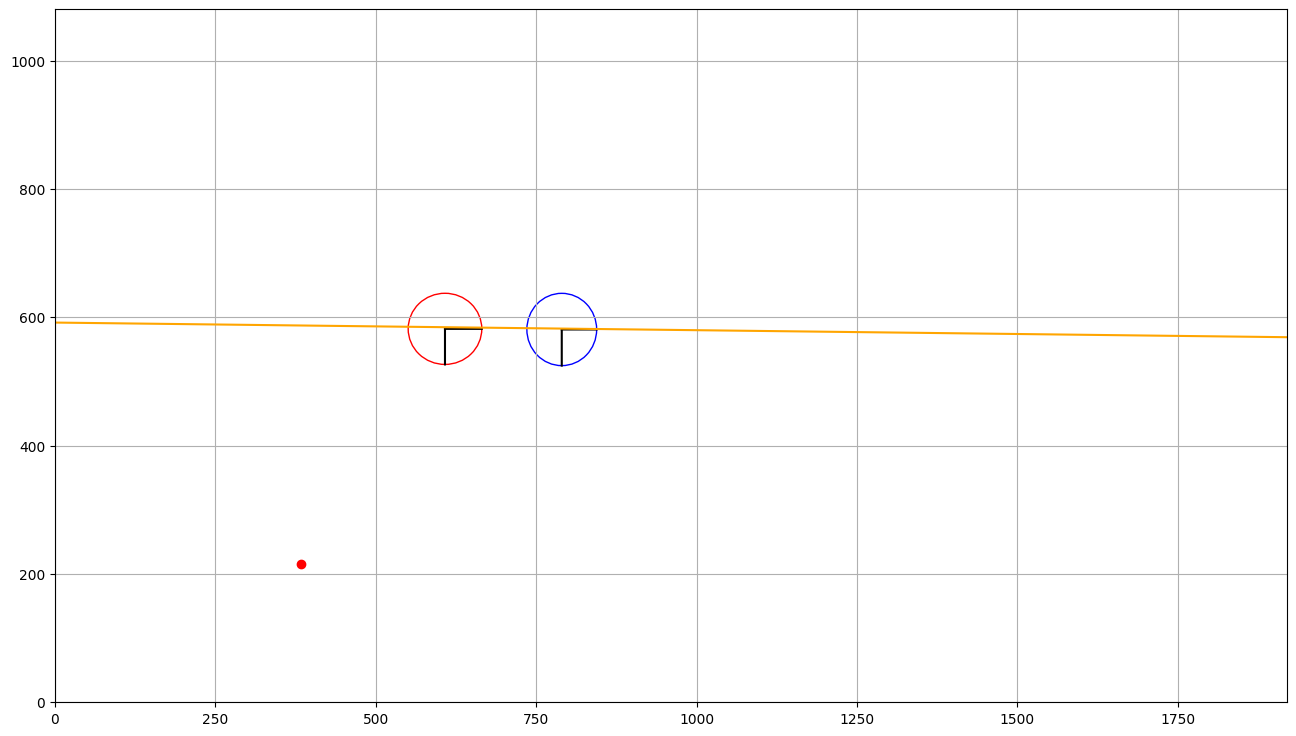

{'Ry_x': -1.1365207692126576e-05, 'Ry_z': 0.2568298606099628, 'Fy_x': -8.196223406115411e-07, 'Fy_z': 0.2613723913311994, 'r_Cf_Cr_x': 181.99033660600298, 'r_Cf_Cr_z': -0.9725647864910343, 'r_Cr_O_x': 224.00106398940443, 'r_Cr_O_z': 365.9684410278786, 'r_P_S_x': 0.9999974861660557, 'r_P_S_z': 0.002164085566933416}


In [17]:
ell_f = EllipseModel()
ell_f.estimate(points_f)
residuals_f = ell_f.residuals(points_f)
xc_f, yc_f, a_f, b_f, theta_f = ell_f.params


xc_f = xc_f * screen_resolution[0]
yc_f = screen_resolution[1] * (1 - yc_f)
a_f = a_f * screen_resolution[1]
b_f = b_f * screen_resolution[0]

ellipse_front = {'center':(xc_f, yc_f), 'major_axis': b_f, 'minor_axis': a_f, 'angle': theta_f}

if a_f < b_f:
    cam_angle_f_2 = np.arccos(a_f/b_f)
elif a_f >= b_f:
    cam_angle_f_2 = np.arccos(b_f/a_f)


ell_r = EllipseModel()
ell_r.estimate(points_r)
residuals_r = ell_r.residuals(points_r)
xc_r, yc_r, a_r, b_r, theta_r = ell_r.params


xc_r = xc_r * screen_resolution[0]
yc_r = screen_resolution[1] * (1 - yc_r)
a_r = a_r * screen_resolution[1]
b_r = b_r * screen_resolution[0]

ellipse_rear = {'center':(xc_r, yc_r), 'major_axis': b_r, 'minor_axis': a_r, 'angle': theta_r}

print('a = ', a_r)
print('b = ', b_r)

if a_r < b_r:
    cam_angle_r_2 = np.arccos(a_r/b_r)
elif a_r >= b_r:
    cam_angle_r_2 = np.arccos(b_r/a_r)

a_test = 1
b_test = 1

assert np.arccos(b_test/a_test) == 0, 'Arccos(1) != 0'


slope = (yc_f - yc_r)/(xc_f - xc_r)

print("center_f = ",  (xc_f, yc_f))
print('center_f cov = ', center_f)
print('error in f center = ', np.sqrt(((center_f[0] - xc_f)/xc_f)**2 + ((center_f[1] - yc_f)/yc_f)**2) * 100)
print("angle of rotation f = ",  np.rad2deg(theta_f))
print("axes_f = ", (a_f,b_f))
print('\n')

print("center_r = ",  (xc_r, yc_r))
print('center_r cov = ', center_r)
print('error in r center = ', np.sqrt(((center_r[0] - xc_r)/xc_r)**2 + ((center_r[1] - yc_r)/yc_r)**2) * 100)
print("angle of rotation r = ",  np.degrees(theta_r))
print("axes_r = ", (a_r,b_r))
print('\n')

print("slope = ", slope)
print('angle to camera f = ', np.rad2deg(cam_angle_f_2))
print('angle to camera r = ', np.rad2deg(cam_angle_r_2))

print('Assumed origin = ', assumed_origin)

# %matplotlib qt

plt.figure(figsize=(16, 9))
plt.gca().set_aspect('equal')

ell_patch_f = Ellipse((xc_f, yc_f), width = 2*a_f, height = 2*b_f,
                      angle = -theta_f*180/np.pi, edgecolor='blue', facecolor='none')

ell_patch_r = Ellipse((xc_r, yc_r), width = 2*a_r, height = 2*b_r,
                      angle = theta_r*180/np.pi, edgecolor='red', facecolor='none')



unit_vectors_f, unit_vectors_r = calc_unit_vectors(ellipse_front, ellipse_rear)

plt.gca().add_patch(ell_patch_f)
plt.gca().add_patch(ell_patch_r)

plt.plot(unit_vectors_f[0][0], unit_vectors_f[0][1], unit_vectors_f[1][0], unit_vectors_f[1][1], color = 'black')
plt.plot(unit_vectors_r[0][0], unit_vectors_r[0][1], unit_vectors_r[1][0], unit_vectors_r[1][1], color = 'black')
plt.plot(x_projection, y_projection, color = 'orange')
plt.plot(assumed_origin[0], assumed_origin[1], 'ro')

plt.xlim(0, screen_resolution[0])
plt.ylim(0, screen_resolution[1])

plt.grid()
plt.show()



imgdata_single = {
    'Ry_x': np.sin(cam_angle_r_2)*np.cos(theta_r),
    'Ry_z': np.sin(cam_angle_r_2)*np.sin(theta_r),
    'Fy_x': np.sin(cam_angle_f_2)*np.cos(theta_f),
    'Fy_z': np.sin(cam_angle_f_2)*np.sin(theta_f),
    'r_Cf_Cr_x': xc_f-xc_r,
    'r_Cf_Cr_z': yc_f-yc_r,
    'r_Cr_O_x': xc_r - assumed_origin[0],
    'r_Cr_O_z': yc_r - assumed_origin[1],
    'r_P_S_x': (np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.sin(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) + np.sin(cam_angle_r_2)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2),
    'r_P_S_z': (np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) - np.sin(cam_angle_r_2)*np.sin(theta_f)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2)
}

print(imgdata_single)

In [ ]:
'Ry_x': np.sin(cam_angle_r_2)*np.cos(theta_r),
    'Ry_z': np.sin(cam_angle_r_2)*np.sin(theta_r),
    'Fy_x': np.sin(cam_angle_f_2)*np.cos(theta_f),
    'Fy_z': np.sin(cam_angle_f_2)*np.sin(theta_f),
    'r_Cf_Cr_x': xc_f-xc_r,
    'r_Cf_Cr_z': yc_f-yc_r,
    'r_Cr_O_x': xc_r - assumed_origin[0],
    'r_Cr_O_z': yc_r - assumed_origin[1],
    'r_P_S_x': (np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.sin(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) + np.sin(cam_angle_r_2)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2),
    'r_P_S_z': (np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) - np.sin(cam_angle_r_2)*np.sin(theta_f)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2)
}

print('angle r cam = ', cam_angle_r_2)
print('angle f cam = ', cam_angle_f_2)
print('theta r = ', theta_r)
print('theta f = ', theta_f)
print('x')

In [26]:
imgdata = {
        'Ry_x': [],
        'Ry_z': [],
        'Fy_x': [],
        'Fy_z': [],
        'r_Cf_Cr_x': [],
        'r_Cf_Cr_z': [],
        'r_Cr_O_x': [],
        'r_Cr_O_z': [],
        'r_P_S_x': [],
        'r_P_S_z': []
    }

for i in range(417, 418):
    file = f'/home/eimolgon/Documents/PhD-Project/Video2Dynamics/data/gopro_test_1_1_resize_annotation_161025/labels/Train/frame_000{i}.txt'

    ellipses = readEllipse(file)

    major_f = ellipses[0]['major_axis'] 
    minor_f = ellipses[0]['minor_axis'] 
    center_f = ellipses[0]['center']
    center_f[0] = center_f[0]*screen_resolution[0]
    center_f[1] = screen_resolution[1] * (1 - center_f[1])
    angle_f = ellipses[0]['angle']
    points_f = ellipses[0]['points']

    major_r = ellipses[1]['major_axis'] 
    minor_r = ellipses[1]['minor_axis'] 
    center_r = ellipses[1]['center']
    center_r[0] = center_r[0]*screen_resolution[0]
    center_r[1] = screen_resolution[1] * (1 - center_r[1])
    angle_r = ellipses[1]['angle']
    points_r = ellipses[1]['points']

    centers_x = [center_r[0], center_f[0]]
    centers_y = [center_r[1], center_f[1]]
    slope = (center_f[1]-center_r[1])/(center_f[0]-center_r[0])


    x_diff = center_f[0] - center_r[0]
    y_diff = center_f[1] - center_r[1]
    w_screen = np.sqrt(x_diff**2 + y_diff**2)

    projection_coefficients = np.polyfit(centers_x, centers_y, 1)
    wheelbase_projection = np.poly1d(projection_coefficients)
    x_projection = np.linspace(0, screen_resolution[0], 100)
    y_projection = wheelbase_projection(x_projection)

    ell_f = EllipseModel()
    ell_f.estimate(points_f)
    residuals_f = ell_f.residuals(points_f)
    xc_f, yc_f, a_f, b_f, theta_f = ell_f.params


    xc_f = xc_f * screen_resolution[0]
    yc_f = screen_resolution[1] * (1 - yc_f)
    a_f = a_f * screen_resolution[1]
    b_f = b_f * screen_resolution[0]

    ellipse_front = {'center':(xc_f, yc_f), 'major_axis': b_f, 'minor_axis': a_f, 'angle': theta_f}

    if a_f < b_f:
        cam_angle_f_2 = np.arccos(a_f/b_f)
    elif a_f >= b_f:
        cam_angle_f_2 = np.arccos(b_f/a_f)

    ell_r = EllipseModel()
    ell_r.estimate(points_r)
    residuals_r = ell_r.residuals(points_r)
    xc_r, yc_r, a_r, b_r, theta_r = ell_r.params


    xc_r = xc_r * screen_resolution[0]
    yc_r = screen_resolution[1] * (1 - yc_r)
    a_r = a_r * screen_resolution[1]
    b_r = b_r * screen_resolution[0]

    ellipse_rear = {'center':(xc_r, yc_r), 'major_axis': b_r, 'minor_axis': a_r, 'angle': theta_r}

    if a_r < b_r:
        cam_angle_r_2 = np.arccos(a_r/b_r)
    elif a_r >= b_r:
        cam_angle_r_2 = np.arccos(b_r/a_r)

    
    imgdata['Ry_x'].append(np.sin(cam_angle_r_2)*np.cos(theta_r)),
    imgdata['Ry_z'].append(np.sin(cam_angle_r_2)*np.sin(theta_r)),
    imgdata['Fy_x'].append(np.sin(cam_angle_f_2)*np.cos(theta_f)),
    imgdata['Fy_z'].append(np.sin(cam_angle_f_2)*np.sin(theta_f)),
    imgdata['r_Cf_Cr_x'].append(xc_f-xc_r),
    imgdata['r_Cf_Cr_z'].append(yc_f-yc_r),
    imgdata['r_Cr_O_x'].append(xc_r - assumed_origin[0]),
    imgdata['r_Cr_O_z'].append(yc_r - assumed_origin[1]),
    imgdata['r_P_S_x'].append((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.sin(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) + np.sin(cam_angle_r_2)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2)),
    imgdata['r_P_S_z'].append((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))*np.cos(theta_f)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2) - np.sin(cam_angle_r_2)*np.sin(theta_f)*np.sin(theta_f - theta_r)*np.cos(cam_angle_f_2)/np.sqrt((np.sin(cam_angle_f_2)*np.cos(cam_angle_r_2) - np.sin(cam_angle_r_2)*np.cos(cam_angle_f_2)*np.cos(theta_f - theta_r))**2 + np.sin(cam_angle_r_2)**2*np.sin(theta_f - theta_r)**2))    


print(imgdata)

{'Ry_x': [-1.1365207692126576e-05], 'Ry_z': [0.2568298606099628], 'Fy_x': [-8.196223406115411e-07], 'Fy_z': [0.2613723913311994], 'r_Cf_Cr_x': [181.99033660600298], 'r_Cf_Cr_z': [-0.9725647864910343], 'r_Cr_O_x': [224.00106398940443], 'r_Cr_O_z': [365.9684410278786], 'r_P_S_x': [0.9999974861660557], 'r_P_S_z': [0.002164085566933416]}


In [28]:
for i, j in zip(imgdata_single.values(), imgdata.values()):
    print(i - j[0])

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [ ]:
with open(f'data4model_gopro_check.json', 'w') as f:
    json.dump(imgdata, f)